# 🏋️ Gym Workout Recommendation — scikit-learn

**No TensorFlow required** — lightweight, runs on any machine.

| | |
|---|---|
| **Dataset** | `gym_members_exercise_tracking.csv` |
| **Libraries** | pandas · numpy · scikit-learn · matplotlib · seaborn · joblib |
| **Model** | Random Forest / Gradient Boosting / Decision Tree → exported as JSON for Flutter |
| **Goal** | Classify workout type from member biometrics |


## 📦 Step 0 — Install Dependencies

Run once. All packages are lightweight and pip-installable.

```bash
pip install pandas scikit-learn matplotlib seaborn joblib
```


---
## 📂 Step 1 — Load Data


In [ ]:
import os
import pandas as pd

# ── Configuration ────────────────────────────────────────────────────────────
FILE_PATH = r"data\gym_members_exercise_tracking.csv"
OUTPUT_DIR = os.path.dirname(FILE_PATH)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load ─────────────────────────────────────────────────────────────────────
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Dataset not found at: {FILE_PATH}")

try:
    df = pd.read_csv(FILE_PATH, encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(FILE_PATH, encoding="latin1")

print(f"✅ Loaded: {FILE_PATH}")
print(f"\n📊 Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print("\n📌 Column list:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")

print("\n🔍 First 5 rows:")
df.head()


✅ Loaded: E:\disktop\gym_members_exercise_tracking.csv

📊 Rows: 973  |  Columns: 15

📌 Column list:
   1. Age
   2. Gender
   3. Weight (kg)
   4. Height (m)
   5. Max_BPM
   6. Avg_BPM
   7. Resting_BPM
   8. Session_Duration (hours)
   9. Calories_Burned
  10. Workout_Type
  11. Fat_Percentage
  12. Water_Intake (liters)
  13. Workout_Frequency (days/week)
  14. Experience_Level
  15. BMI

🔍 First 5 rows:


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [2]:
df.head()


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [3]:
print("=== Missing Values ===")
nulls = df.isnull().sum()
if nulls.sum() == 0:
    print("✅ No missing values found")
else:
    print(nulls[nulls > 0])

print("\n=== Descriptive Statistics ===")
df.describe().round(2)


=== Missing Values ===
✅ No missing values found

=== Descriptive Statistics ===


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00
mean,38.68,73.85,1.72,179.88,143.77,62.22,1.26,905.42,24.98,2.63,3.32,1.81,24.91
std,12.18,21.21,0.13,11.53,14.35,7.33,0.34,272.64,6.26,0.60,0.91,0.74,6.66
min,18.00,40.00,1.50,160.00,120.00,50.00,0.50,303.00,10.00,1.50,2.00,1.00,12.32
25%,28.00,58.10,1.62,170.00,131.00,56.00,1.04,720.00,21.30,2.20,3.00,1.00,20.11
50%,40.00,70.00,1.71,180.00,143.00,62.00,1.26,893.00,26.20,2.60,3.00,2.00,24.16
75%,49.00,86.00,1.80,190.00,156.00,68.00,1.46,1076.00,29.30,3.10,4.00,2.00,28.56
max,59.00,129.90,2.00,199.00,169.00,74.00,2.00,1783.00,35.00,3.70,5.00,3.00,49.84


---
## 🔍 Step 2 — Exploratory Data Analysis (EDA)

Four panels:
1. **Workout Type Distribution** — target class balance  
2. **Gender Distribution** — pie chart  
3. **BMI Histogram** — with clinical threshold lines  
4. **BMI by Workout Type** — box plot to spot signal


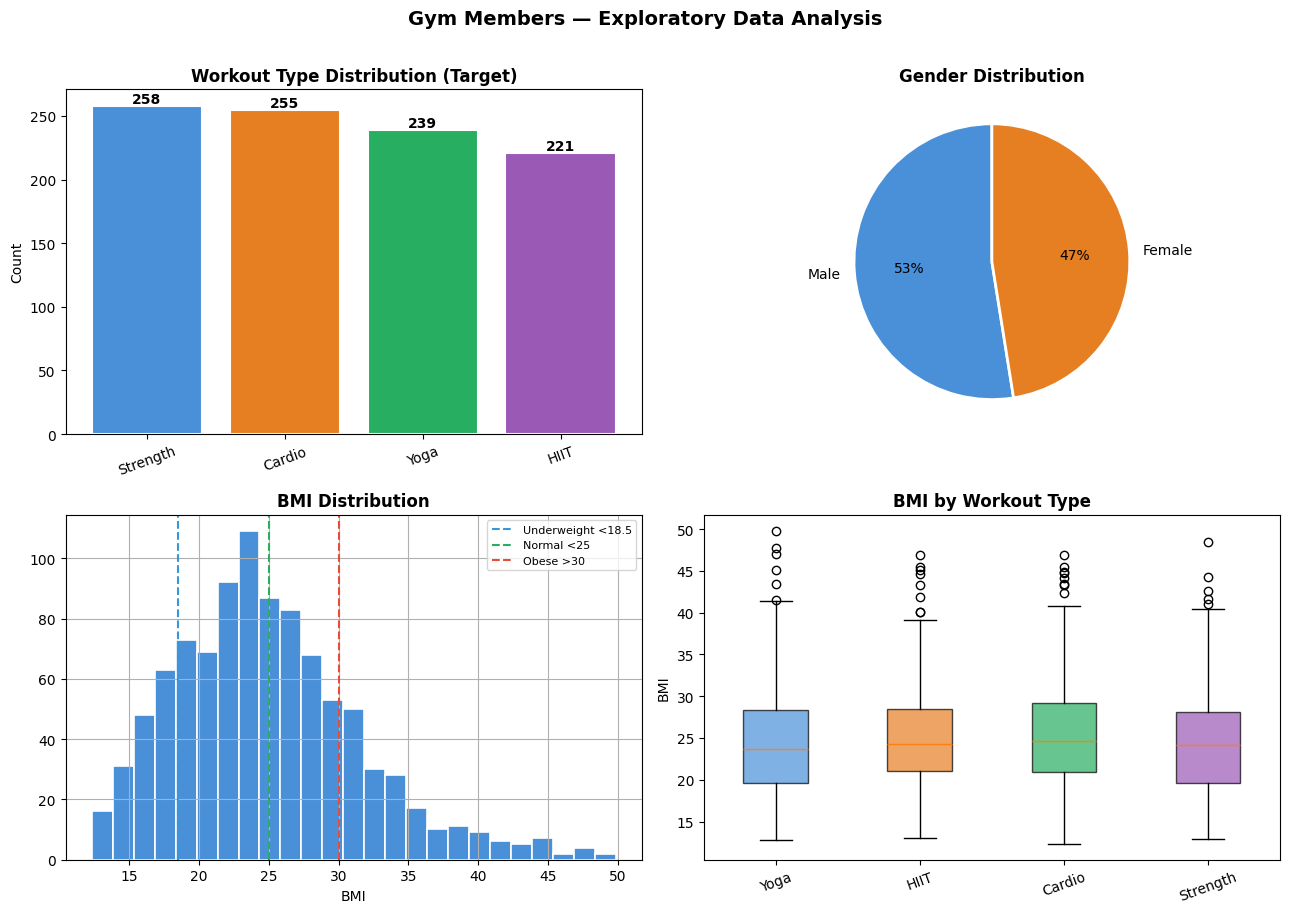

✅ EDA charts saved.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

WORKOUT_COL    = "Workout_Type"
EXPERIENCE_COL = "Experience_Level"
BMI_COL        = "BMI"
GENDER_COL     = "Gender"

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Gym Members — Exploratory Data Analysis", fontsize=14, fontweight="bold", y=1.01)

# 1 ─ Workout type (target) distribution
if WORKOUT_COL in df.columns:
    counts = df[WORKOUT_COL].value_counts()
    bars = axes[0, 0].bar(
        counts.index, counts.values,
        color=["#4A90D9", "#E67E22", "#27AE60", "#9B59B6"],
        edgecolor="white", linewidth=1.5,
    )
    axes[0, 0].set_title("Workout Type Distribution (Target)", fontweight="bold")
    for bar, val in zip(bars, counts.values):
        axes[0, 0].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(val), ha="center", fontsize=10, fontweight="bold",
        )
    axes[0, 0].tick_params(axis="x", rotation=20)
    axes[0, 0].set_ylabel("Count")

# 2 ─ Gender pie chart
if GENDER_COL in df.columns:
    df[GENDER_COL].value_counts().plot(
        kind="pie", ax=axes[0, 1], autopct="%1.0f%%",
        colors=["#4A90D9", "#E67E22"], startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2),
    )
    axes[0, 1].set_title("Gender Distribution", fontweight="bold")
    axes[0, 1].set_ylabel("")

# 3 ─ BMI histogram
if BMI_COL in df.columns:
    df[BMI_COL].hist(ax=axes[1, 0], bins=25, color="#4A90D9", edgecolor="white", linewidth=1.2)
    axes[1, 0].set_title("BMI Distribution", fontweight="bold")
    axes[1, 0].axvline(18.5, color="#3498DB", linestyle="--", lw=1.5, label="Underweight <18.5")
    axes[1, 0].axvline(25,   color="#27AE60", linestyle="--", lw=1.5, label="Normal <25")
    axes[1, 0].axvline(30,   color="#E74C3C", linestyle="--", lw=1.5, label="Obese >30")
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].set_xlabel("BMI")

# 4 ─ BMI by workout type (box plot)
if BMI_COL in df.columns and WORKOUT_COL in df.columns:
    workout_types  = df[WORKOUT_COL].unique()
    data_by_type   = [df[df[WORKOUT_COL] == wt][BMI_COL].dropna().values for wt in workout_types]
    bp = axes[1, 1].boxplot(data_by_type, tick_labels=workout_types, patch_artist=True)
    colors = ["#4A90D9", "#E67E22", "#27AE60", "#9B59B6"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1, 1].set_title("BMI by Workout Type", fontweight="bold")
    axes[1, 1].tick_params(axis="x", rotation=20)
    axes[1, 1].set_ylabel("BMI")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_charts.png"), dpi=120, bbox_inches="tight")
plt.show()
print("✅ EDA charts saved.")


---
## ⚙️ Step 3 — Preprocessing & Feature Engineering

**Pipeline:**
1. Select biometric features  
2. Label-encode categorical columns (Gender → 0 / 1)  
3. Label-encode the target (`Workout_Type`)  
4. Standard-scale all numeric features  
5. Stratified 80 / 20 train–test split  
6. Persist scaler + encoders for inference


In [5]:
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Feature selection ────────────────────────────────────────────────────────
FEATURE_COLS = [
    "Age",
    "Gender",
    "Weight (kg)",
    "Height (m)",
    "BMI",
    "Experience_Level",
]
TARGET_COL = "Workout_Type"

# Keep only columns that actually exist in the dataset
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f"✅ Features  : {FEATURE_COLS}")
print(f"🎯 Target    : {TARGET_COL}")

# ── Clean working copy ───────────────────────────────────────────────────────
data = df[FEATURE_COLS + [TARGET_COL]].dropna().copy()
print(f"\n📦 Rows after dropping NaN: {len(data)}")

# ── Encode categorical feature columns (e.g. Gender) ────────────────────────
label_encoders: dict[str, LabelEncoder] = {}
for col in data.select_dtypes(include="object").columns:
    if col == TARGET_COL:
        continue
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"   Encoded [{col}]: {mapping}")

# ── Encode target ─────────────────────────────────────────────────────────────
target_enc = LabelEncoder()
data[TARGET_COL] = target_enc.fit_transform(data[TARGET_COL].astype(str))
CLASS_NAMES = list(target_enc.classes_)
NUM_CLASSES  = len(CLASS_NAMES)
print(f"\n🏷️  Classes ({NUM_CLASSES}): {CLASS_NAMES}")

# ── Build X / y ───────────────────────────────────────────────────────────────
X = data[FEATURE_COLS].values.astype(np.float32)
y = data[TARGET_COL].values.astype(int)

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Stratified split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n📊 Train: {len(X_train)}  |  Test: {len(X_test)}")

# ── Persist artefacts ─────────────────────────────────────────────────────────
joblib.dump(scaler,         os.path.join(OUTPUT_DIR, "scaler.pkl"))
joblib.dump(target_enc,     os.path.join(OUTPUT_DIR, "target_encoder.pkl"))
joblib.dump(label_encoders, os.path.join(OUTPUT_DIR, "label_encoders.pkl"))
print("✅ Scaler and encoders saved.")


✅ Features  : ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'BMI', 'Experience_Level']
🎯 Target    : Workout_Type

📦 Rows after dropping NaN: 973
   Encoded [Gender]: {'Female': 0, 'Male': 1}

🏷️  Classes (4): ['Cardio', 'HIIT', 'Strength', 'Yoga']

📊 Train: 778  |  Test: 195
✅ Scaler and encoders saved.


---
## 🌲 Step 4 — Model Training

Three tree-based classifiers are evaluated; the one with the best test accuracy
is serialised as the production model.

| Model | Rationale |
|---|---|
| **Random Forest** | Ensemble baseline; robust to overfitting |
| **Gradient Boosting** | Often best accuracy via sequential boosting |
| **Decision Tree** | Interpretable single-tree baseline |


In [6]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# ── Model zoo ─────────────────────────────────────────────────────────────────
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42,
    ),
}

# ── Train & evaluate ──────────────────────────────────────────────────────────
results: dict[str, dict] = {}
print("⏳ Training …\n")

for name, clf in models.items():
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))
    results[name] = {"model": clf, "train": train_acc, "test": test_acc}
    print(f"  {name:26s}  Train: {train_acc*100:5.1f}%  |  Test: {test_acc*100:5.1f}%")

# ── Select best ───────────────────────────────────────────────────────────────
best_name  = max(results, key=lambda k: results[k]["test"])
best_model = results[best_name]["model"]
best_acc   = results[best_name]["test"]

print(f"\n🏆 Best model: {best_name}  →  Test accuracy {best_acc*100:.1f}%")

# ── Persist best model ────────────────────────────────────────────────────────
joblib.dump(best_model, os.path.join(OUTPUT_DIR, "gym_model.pkl"))
print("✅ Best model saved.")


⏳ Training …

  Random Forest               Train:  94.0%  |  Test:  20.0%
  Gradient Boosting           Train: 100.0%  |  Test:  25.1%
  Decision Tree               Train:  40.1%  |  Test:  19.0%

🏆 Best model: Gradient Boosting  →  Test accuracy 25.1%
✅ Best model saved.


---
## 📈 Step 5 — Model Evaluation

- **Classification report** — per-class precision, recall, F1  
- **Confusion matrix** — heatmap visualisation  
- **Feature importances** — which biometrics drive the prediction


=== Classification Report ===
              precision    recall  f1-score   support

      Cardio       0.27      0.29      0.28        51
        HIIT       0.19      0.16      0.17        44
    Strength       0.35      0.35      0.35        52
        Yoga       0.17      0.19      0.18        48

    accuracy                           0.25       195
   macro avg       0.25      0.25      0.25       195
weighted avg       0.25      0.25      0.25       195



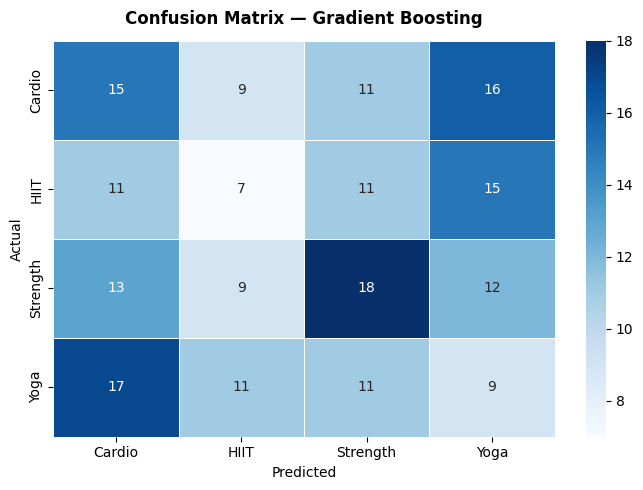

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_model.predict(X_test)

# ── Classification report ─────────────────────────────────────────────────────
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# ── Confusion matrix heatmap ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
)
plt.title(f"Confusion Matrix — {best_name}", fontweight="bold", pad=12)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=120, bbox_inches="tight")
plt.show()


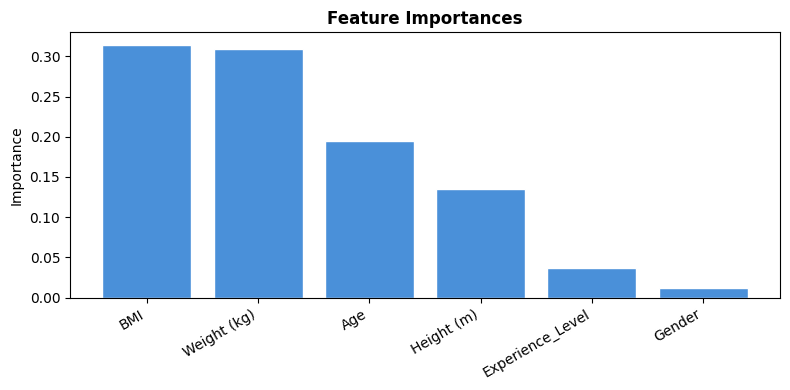


=== Feature Importances (ranked) ===
  BMI                   ████████████                              31.4%
  Weight (kg)           ████████████                              30.9%
  Age                   ███████                                   19.4%
  Height (m)            █████                                     13.5%
  Experience_Level      █                                         3.6%
  Gender                                                          1.2%


In [8]:
# ── Feature importances ───────────────────────────────────────────────────────
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    idx = np.argsort(importances)[::-1]

    plt.figure(figsize=(8, 4))
    plt.bar(
        [FEATURE_COLS[i] for i in idx],
        importances[idx],
        color="#4A90D9", edgecolor="white",
    )
    plt.title("Feature Importances", fontweight="bold")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=120, bbox_inches="tight")
    plt.show()

    print("\n=== Feature Importances (ranked) ===")
    for i in idx:
        bar = "█" * int(importances[i] * 40)
        print(f"  {FEATURE_COLS[i]:20s}  {bar:40s}  {importances[i]*100:.1f}%")


---
## 📱 Step 6 — Export Model to JSON (Flutter-ready)

Because TFLite is not available, we serialise the full decision-tree forest as a
**plain JSON file** that can be executed in Dart with zero ML dependencies.

The JSON contains:
- `model_type` — class name of the winning estimator  
- `scaler` — `mean` + `scale` arrays for manual StandardScaler inference  
- `feature_names` / `class_names` — metadata  
- `trees` — nested dict representation of every decision tree


In [9]:
import json

def _extract_tree(tree) -> dict:
    """Recursively serialise a single sklearn DecisionTree to a nested dict."""
    t = tree.tree_

    def recurse(node: int) -> dict:
        if t.children_left[node] == -1:                      # leaf
            return {"leaf": True, "value": int(np.argmax(t.value[node]))}
        return {
            "leaf":      False,
            "feature":   int(t.feature[node]),
            "threshold": float(round(t.threshold[node], 6)),
            "left":      recurse(t.children_left[node]),
            "right":     recurse(t.children_right[node]),
        }

    return recurse(0)


def export_model_to_json(
    model, scaler, feature_cols: list[str], class_names: list[str], output_path: str
) -> dict:
    """
    Export any tree-based sklearn model (RF, GB, DT) as a self-contained JSON
    that can be used for inference in Flutter / Dart without any ML library.
    """
    model_name = type(model).__name__

    if model_name == "GradientBoostingClassifier":
        # estimators_ shape: (n_estimators, n_classes) or (n_estimators, 1)
        trees = [_extract_tree(est) for stage in model.estimators_ for est in stage]
    elif model_name == "RandomForestClassifier":
        trees = [_extract_tree(est) for est in model.estimators_]
    else:                                                      # single DecisionTree
        trees = [_extract_tree(model)]

    payload = {
        "model_type":    model_name,
        "n_features":    len(feature_cols),
        "feature_names": feature_cols,
        "class_names":   class_names,
        "n_classes":     len(class_names),
        "scaler": {
            "mean":  [round(float(v), 6) for v in scaler.mean_],
            "scale": [round(float(v), 6) for v in scaler.scale_],
        },
        "trees": trees,
    }

    with open(output_path, "w", encoding="utf-8") as fh:
        json.dump(payload, fh, ensure_ascii=False, separators=(",", ":"))

    size_kb = os.path.getsize(output_path) / 1024
    print(f"✅ Model exported successfully!")
    print(f"   Size  : {size_kb:.1f} KB")
    print(f"   Path  : {output_path}")
    return payload


JSON_PATH  = os.path.join(OUTPUT_DIR, "gym_model.json")
model_data = export_model_to_json(best_model, scaler, FEATURE_COLS, CLASS_NAMES, JSON_PATH)


✅ Model exported successfully!
   Size  : 1250.5 KB
   Path  : E:\disktop\gym_model.json


In [10]:
def predict_from_json(model_data: dict, raw_input: list[float]) -> tuple[str, float, list[int]]:
    """
    Pure-Python inference from the exported JSON — mirrors the Dart implementation
    exactly, so you can validate predictions before deploying to Flutter.
    """
    mean  = model_data["scaler"]["mean"]
    scale = model_data["scaler"]["scale"]
    x     = [(raw_input[i] - mean[i]) / scale[i] for i in range(len(raw_input))]

    def traverse(node: dict, x: list[float]) -> int:
        if node["leaf"]:
            return node["value"]
        return traverse(
            node["left"] if x[node["feature"]] <= node["threshold"] else node["right"], x
        )

    votes = [0] * model_data["n_classes"]
    for tree in model_data["trees"]:
        votes[traverse(tree, x)] += 1

    best_idx   = votes.index(max(votes))
    confidence = max(votes) / len(model_data["trees"]) * 100
    return model_data["class_names"][best_idx], confidence, votes


# ── Sanity check: 28-year-old female, 75 kg, 1.75 m, BMI 24.5, intermediate ──
sample = [28, 0, 75.0, 1.75, 24.5, 2]
label, conf, votes = predict_from_json(model_data, sample)

print("=== Prediction Test ===")
print(f"  Input       : {dict(zip(FEATURE_COLS, sample))}")
print(f"  Recommended : {label}")
print(f"  Confidence  : {conf:.1f}%")
print("\n  Full probability breakdown:")
for cls, v in zip(CLASS_NAMES, votes):
    pct = v / len(model_data["trees"]) * 100
    bar = "█" * int(pct / 3)
    print(f"    {cls:12s}  {bar:35s}  {pct:.1f}%")


=== Prediction Test ===
  Input       : {'Age': 28, 'Gender': 0, 'Weight (kg)': 75.0, 'Height (m)': 1.75, 'BMI': 24.5, 'Experience_Level': 2}
  Recommended : Cardio
  Confidence  : 100.0%

  Full probability breakdown:
    Cardio        █████████████████████████████████    100.0%
    HIIT                                               0.0%
    Strength                                           0.0%
    Yoga                                               0.0%


In [11]:
# ── Print scaler constants ready to paste into Dart ──────────────────────────
print("=== Copy these constants into your Dart file ===\n")
print("static const List<double> scalerMean = [")
print("  " + ", ".join(f"{v:.6f}" for v in scaler.mean_))
print("];\n")
print("static const List<double> scalerScale = [")
print("  " + ", ".join(f"{v:.6f}" for v in scaler.scale_))
print("];\n")
print("// Feature order:")
for i, col in enumerate(FEATURE_COLS):
    print(f"//   [{i}] {col}")


=== Copy these constants into your Dart file ===

static const List<double> scalerMean = [
  38.683453, 0.525180, 73.854676, 1.722580, 24.912127, 1.809866
];

static const List<double> scalerScale = [
  12.174667, 0.499366, 21.196600, 0.127654, 6.657456, 0.739313
];

// Feature order:
//   [0] Age
//   [1] Gender
//   [2] Weight (kg)
//   [3] Height (m)
//   [4] BMI
//   [5] Experience_Level


---
## 📱 Step 7 — Flutter Integration Guide

**No ML library required in Flutter.**

### 1. Copy the asset
Place `gym_model.json` inside your Flutter project's `assets/` folder.

### 2. Register in `pubspec.yaml`
```yaml
flutter:
  assets:
    - assets/gym_model.json
```


---
## ✅ Output Summary

| File | Purpose |
|---|---|
| `gym_model.json` | ⭐ Primary artefact — copy to Flutter `assets/` |
| `gym_model.pkl` | Python-only pickled model |
| `scaler.pkl` | Python-only pickled scaler |
| `eda_charts.png` | Exploratory visualisations |
| `confusion_matrix.png` | Evaluation heatmap |
| `feature_importance.png` | Feature ranking chart |

---
### 🎯 Required Python packages (all lightweight)
```
pip install pandas scikit-learn matplotlib seaborn joblib
```
**2+2=1**
